2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5132 - loss: 2.6786 - val_accuracy: 0.6360 - val_loss: 1.8228
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6834 - loss: 1.5335 - val_accuracy: 0.7060 - val_loss: 1.3646
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7519 - loss: 1.1730 - val_accuracy: 0.7390 - val_loss: 1.1776
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7972 - loss: 0.9605 - val_accuracy: 0.7570 - val_loss: 1.0805
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8257 - loss: 0.8044 - val_accuracy: 0.7760 - val_loss: 1.0056


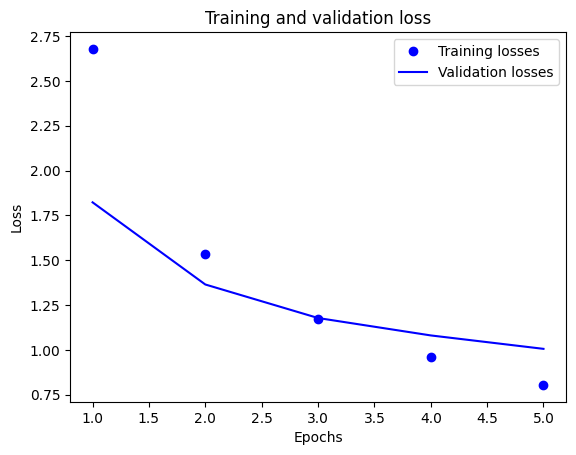

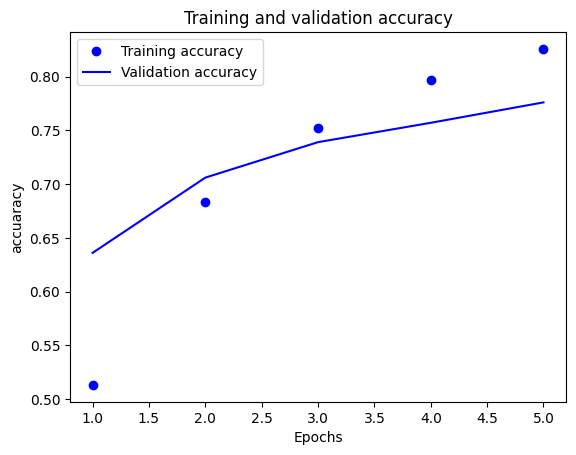

In [2]:
#STEP 1:
#loading the REUTERS dataset
from tensorflow.keras.datasets import reuters

#STEP 2:
#splitting the dataset
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

#STEP 3:
len(train_data)

#STEP 4:
len(test_data)

#STEP 5:
train_data.shape

#STEP 6:
#Decoding newswires back to text
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_text(text):
# Offset by 3 because 0, 1, and 2 are reserved for padding, start, and unknown
  return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])

decode_text(train_data[10])

#STEP 7:
#preparing the data
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    results[i, sequence] = 1
  return results

#STEP 8:
X_train = vectorize_sequences(train_data)
X_test = vectorize_sequences(test_data)

#STEP 9:
def to_one_hot(labels, dimension=46):
  results = np.zeros((len(labels), dimension))
  for i, label in enumerate(labels):
    results[i, label] = 1.
  return results

y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

#STEP 10:
one_hot_train_labels = to_one_hot(train_labels)
one_hot_test_labels = to_one_hot(test_labels)

#STEP 11:
from keras import utils

one_hot_train_labels = utils.to_categorical(train_labels)
one_hot_test_labels = utils.to_categorical(test_labels)

#STEP 12:
#Build the model
from keras import models
from keras import layers

model = models.Sequential([
  layers.Dense(64, activation="relu", input_shape=(10000, )),
  layers.Dense(64, activation="relu"),
  layers.Dense(46, activation="softmax")
])

#STEP 13:
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

#STEP 14:
#validate the model
X_val = X_train[:1000]
partial_X_train = X_train[1000:]
y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

#STEP 15:
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=5,
                    batch_size=512,
                    validation_data=(X_val, y_val))

#STEP 16:
history_dict = history.history
history_dict.keys()

#STEP 17:
import matplotlib.pyplot as plt

loss_values = history_dict["loss"]
val_loss_values = history_dict['val_loss']
epochs = np.arange(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training losses')
plt.plot(epochs, val_loss_values, 'b', label='Validation losses')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#STEP 18:
accuracy_values = history_dict["accuracy"]
val_accuracy_values = history_dict['val_accuracy']
epochs = np.arange(1, len(accuracy_values) + 1)

plt.plot(epochs, accuracy_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuaracy')
plt.legend()
plt.show()